<a href="https://colab.research.google.com/github/gunjjoshi/optimized-frft/blob/main/frft_april2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [7]:
def compute_frft_eigenvectors(N, dev):
    s = torch.zeros(N, device=dev)
    s[1] = 1
    s[-1] = 1
    M = torch.zeros((N, N), device=dev)
    dum = s.clone()
    for i in range(N):
        M[:, i] = dum
        dum = torch.roll(dum, 1)
    S = M + torch.diag(torch.fft.fft(s).real)

    r = N // 2
    even = 1 - (N % 2)
    P = torch.zeros((N, N), device=dev)
    P[0, 0] = 1
    for i in range(1, r - even + 1):
        P[i, i] = P[i, N - i] = 1 / math.sqrt(2)
    if even:
        P[r, r] = 1
    for i in range(r + 1, N):
        P[i, i] = -1 / math.sqrt(2)
        P[i, N - i] = 1 / math.sqrt(2)

    CS = P.T @ S @ P
    C2 = CS[:r + 1, :r + 1]
    S2 = CS[r + 1:, r + 1:]

    ec, vc = torch.linalg.eigh(C2)
    es, vs = torch.linalg.eigh(S2)

    qvc = torch.vstack([vc, torch.zeros((N - r - 1, r + 1), device=dev)])
    qvs = torch.vstack([torch.zeros((r + 1, N - r - 1), device=dev), vs])

    SC2 = (P @ qvc)[:, torch.argsort(-ec)]
    SS2 = (P @ qvs)[:, torch.argsort(-es)]

    if N % 2 == 0:
        Evec = torch.zeros((N, N + 1), device=dev)
        Evec[:, 0::2] = SC2
        Evec[:, 1:N:2] = torch.hstack([SS2, torch.zeros((N, 1), device=dev)])
        Evec = Evec[:, :-1]
    else:
        Evec = torch.zeros((N, N), device=dev)
        Evec[:, 0::2] = SC2
        Evec[:, 1:N:2] = SS2

    return Evec.to(torch.complex64)


def _frft_kernel(N, p_tensor, dev):
    """Build FRFT kernel for dimension N with learnable p (stays in graph)."""
    Evec = compute_frft_eigenvectors(N, dev)
    p = p_tensor.to(torch.complex64)
    l = torch.arange(N, device=dev, dtype=torch.float32).to(torch.complex64)
    phases = torch.exp(-1j * math.pi / 2 * p * l)
    return math.sqrt(N) * (Evec @ torch.diag(phases) @ Evec.T)


def _frft_kernel_fixed(N, p_val, dev):
    """Build FRFT kernel for a fixed scalar p (no gradient needed)."""
    Evec = compute_frft_eigenvectors(N, dev)
    l = torch.arange(N, device=dev, dtype=torch.float32).to(torch.complex64)
    p_c = torch.tensor(p_val, dtype=torch.complex64, device=dev)
    phases = torch.exp(-1j * math.pi / 2 * p_c * l)
    return math.sqrt(N) * (Evec @ torch.diag(phases) @ Evec.T)


class LearnableFRFTLayer(nn.Module):
    """
    Learnable FRFT layer. Handles both 2D (H>1) and 1D (H=1) inputs.
    For H=1 inputs (1D signals), only applies FRFT along W dimension.
    Output channels = 2 * input channels (Real and Imag concatenated).
    """
    def __init__(self, initial_order=0.5):
        super().__init__()
        val = math.log(initial_order / (1.0 - initial_order))
        self.raw_order = nn.Parameter(torch.tensor([val], dtype=torch.float32))
        self._eigen_cache = {}

    @property
    def order(self):
        return torch.sigmoid(self.raw_order)

    def _get_eigenvectors(self, N):
        if N not in self._eigen_cache:
            self._eigen_cache[N] = compute_frft_eigenvectors(N, device)
        return self._eigen_cache[N]

    def _build_kernel(self, N):
        Evec = self._get_eigenvectors(N)
        p = self.order.to(torch.complex64)
        l = torch.arange(N, device=device, dtype=torch.float32).to(torch.complex64)
        phases = torch.exp(-1j * math.pi / 2 * p * l)
        return math.sqrt(N) * (Evec @ torch.diag(phases) @ Evec.T)

    def forward(self, x):
        B, C, H, W = x.shape
        x_c = torch.fft.fftshift(x, dim=(-2, -1)).to(torch.complex64)

        if H > 1:
            Kh = self._build_kernel(H)
            x_c = torch.einsum('ij,bcjk->bcik', Kh, x_c)

        Kw = self._build_kernel(W)
        x_c = torch.einsum('bcik,kl->bcil', x_c, Kw)
        x_c = torch.fft.fftshift(x_c, dim=(-2, -1))

        scale = math.sqrt(H * W)
        return torch.cat([x_c.real / scale, x_c.imag / scale], dim=1)


def fixed_frft_magnitude(x, order_val):
    """Apply FRFT at fixed order, return magnitude. Skips H dim if H=1."""
    B, C, H, W = x.shape
    with torch.no_grad():
        Kw = _frft_kernel_fixed(W, order_val, device)
        Kh = _frft_kernel_fixed(H, order_val, device) if H > 1 else None

    x_c = torch.fft.fftshift(x, dim=(-2, -1)).to(torch.complex64)
    if Kh is not None:
        x_c = torch.einsum('ij,bcjk->bcik', Kh, x_c)
    x_c = torch.einsum('bcik,kl->bcil', x_c, Kw)
    x_c = torch.fft.fftshift(x_c, dim=(-2, -1))
    return x_c.abs() / math.sqrt(H * W)


print('Core FRFT layer ready.')

Core FRFT layer ready.


Generating quadrature chirp dataset...
Input shape: torch.Size([1, 1, 64])
Train: 4000 | Test: 1000
Happy — mean: 0.0000, std: 1.0000
Angry — mean: 0.0000, std: 1.0000
(Means and stds should be ~equal)


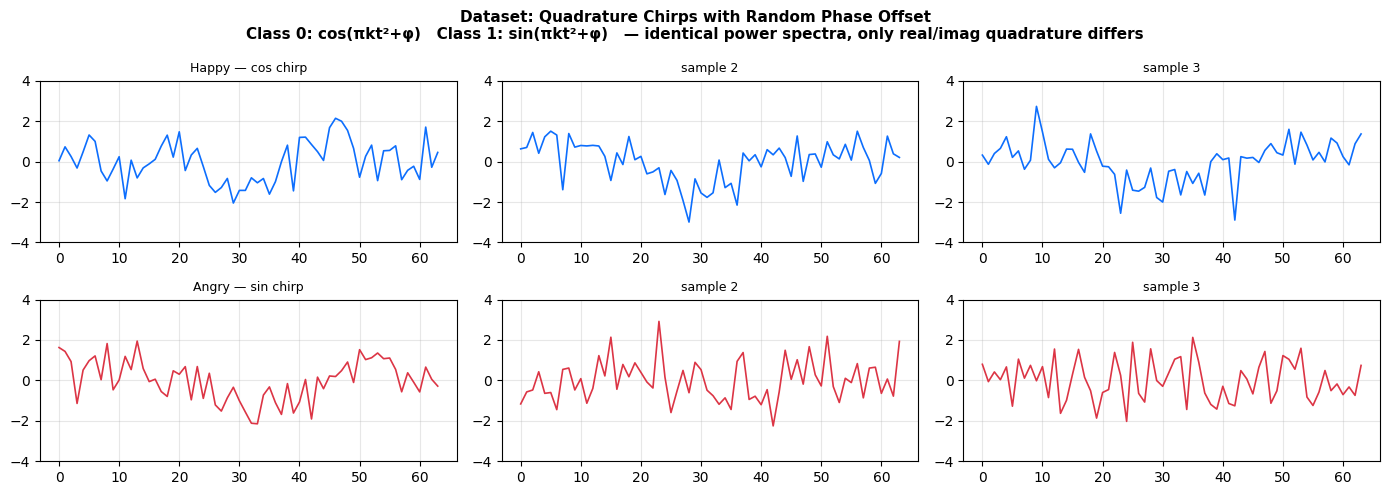

In [8]:
def generate_emotional_speech(N=4000, length=64, seed=0):
    rng = np.random.default_rng(seed)
    X, Y = [], []

    t = np.linspace(-0.5, 0.5, length)
    envelope = np.exp(-32.0 * t ** 2)
    k = 8.0
    noise_std = 0.4

    for i in range(N):
        label = i % 2
        phi = rng.uniform(0, 2 * math.pi)
        noise = noise_std * rng.standard_normal(length)

        if label == 0:
            s = envelope * np.cos(math.pi * k * t ** 2 + phi) + noise
        else:
            s = envelope * np.sin(math.pi * k * t ** 2 + phi) + noise

        s = s - s.mean()
        s = s / (s.std() + 1e-8)
        signal = torch.tensor(s, dtype=torch.float32)

        # Shape: (1, 1, length) — C=1, H=1, W=length
        X.append(signal.view(1, 1, length))
        Y.append(label)

    data_x = torch.stack(X)          # (N, 1, 1, length)
    return torch.utils.data.TensorDataset(data_x, torch.tensor(Y))


print('Generating quadrature chirp dataset...')
torch.manual_seed(0)
np.random.seed(0)
speech_train = generate_emotional_speech(N=4000, length=64, seed=0)
speech_test  = generate_emotional_speech(N=1000, length=64, seed=99)
speech_trainloader = DataLoader(speech_train, batch_size=64, shuffle=True)
speech_testloader  = DataLoader(speech_test,  batch_size=64, shuffle=False)

sample_x, sample_y = speech_train[0]
print(f'Input shape: {sample_x.shape}')   # expect torch.Size([1, 1, 64])
print(f'Train: {len(speech_train)} | Test: {len(speech_test)}')

happy = torch.stack([speech_train[i][0] for i in range(len(speech_train))
                     if speech_train[i][1].item() == 0])
angry = torch.stack([speech_train[i][0] for i in range(len(speech_train))
                     if speech_train[i][1].item() == 1])
print(f'Happy — mean: {happy.mean():.4f}, std: {happy.std():.4f}')
print(f'Angry — mean: {angry.mean():.4f}, std: {angry.std():.4f}')
print('(Means and stds should be ~equal)')

fig, axes = plt.subplots(2, 3, figsize=(14, 5))
fig.suptitle('Dataset: Quadrature Chirps with Random Phase Offset\n'
             'Class 0: cos(πkt²+φ)   Class 1: sin(πkt²+φ)   '
             '— identical power spectra, only real/imag quadrature differs',
             fontweight='bold', fontsize=11)
for row, (imgs, name, color) in enumerate([
        (happy, 'Happy — cos chirp', '#0d6efd'),
        (angry, 'Angry — sin chirp', '#dc3545')]):
    for col in range(3):
        axes[row, col].plot(imgs[col].squeeze().numpy(), color=color, linewidth=1.2)
        axes[row, col].set_title(f'{name}' if col == 0 else f'sample {col+1}', fontsize=9)
        axes[row, col].set_ylim(-4, 4)
        axes[row, col].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dataset_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
class BaselineCNN_Speech(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)


class MagnitudeOnlyFRFT_Speech(nn.Module):
    """FRFT magnitude only — loses quadrature info, cannot distinguish cos/sin chirp."""
    def __init__(self, order=0.5):
        super().__init__()
        self._order_val = order
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(fixed_frft_magnitude(x, self._order_val))


class RealImagFRFT_Speech(nn.Module):
    """Learnable FRFT — finds collapsing angle p, sees spike in Re vs Im channel."""
    def __init__(self, initial_order=0.5):
        super().__init__()
        self.frft = LearnableFRFTLayer(initial_order)
        self.net = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(self.frft(x))


class DeepStackedFRFT_Speech(nn.Module):
    """Two stacked learnable FRFT layers, each with its own p."""
    def __init__(self):
        super().__init__()
        self.frft1 = LearnableFRFTLayer(initial_order=0.3)
        self.conv1 = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(16), nn.ReLU()
        )
        self.frft2 = LearnableFRFTLayer(initial_order=0.7)
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        x = self.conv1(self.frft1(x))
        x = self.conv2(self.frft2(x))
        return self.head(x)


print('Speech emotion models defined.')

Speech emotion models defined.


In [46]:
def train_speech_model(model, name, epochs=30):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    order_params = [p for n, p in model.named_parameters() if 'raw_order' in n]
    other_params = [p for n, p in model.named_parameters() if 'raw_order' not in n]

    if order_params:
        optimizer = optim.Adam([
            {'params': other_params, 'lr': 1e-3},
            {'params': order_params, 'lr': 5e-2}
        ])
    else:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'acc': [], 'loss': [], 'orders': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in speech_trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in speech_testloader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total   += y.size(0)

        acc       = 100 * correct / total
        avg_loss  = running_loss / len(speech_trainloader)
        orders    = [torch.sigmoid(p).item() for n, p in model.named_parameters() if 'raw_order' in n]
        history['acc'].append(acc)
        history['loss'].append(avg_loss)
        history['orders'].append(orders)

        if epoch % 5 == 0 or epoch == epochs - 1:
            order_str = f' | p={[f"{o:.3f}" for o in orders]}' if orders else ''
            print(f'  [{name}] Ep {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%{order_str}')

    return history


print('\nTraining Speech Emotion Recognition models...\n')
speech_results = {}
speech_results['Baseline CNN']               = train_speech_model(BaselineCNN_Speech(),            'Baseline CNN',       epochs=30)
speech_results['Magnitude-only FRFT']        = train_speech_model(MagnitudeOnlyFRFT_Speech(),       'Magnitude FRFT',     epochs=30)
speech_results['Real+Imag FRFT (learnable)'] = train_speech_model(RealImagFRFT_Speech(0.5),         'Real+Imag FRFT',     epochs=30)
speech_results['Deep Stacked FRFT']          = train_speech_model(DeepStackedFRFT_Speech(),          'Deep Stacked FRFT',  epochs=30)

print('\nSpeech Results:')
print('-' * 60)
for name, hist in speech_results.items():
    orders = hist['orders'][-1]
    ostr = f'  p={[f"{o:.3f}" for o in orders]}' if orders else ''
    print(f'  {name:<38} {hist["acc"][-1]:6.2f}%{ostr}')
print('-' * 60)


Training Speech Emotion Recognition models...

  [Baseline CNN] Ep  1/30 | Loss: 0.6972 | Acc: 48.50%
  [Baseline CNN] Ep  6/30 | Loss: 0.6924 | Acc: 49.60%
  [Baseline CNN] Ep 11/30 | Loss: 0.6864 | Acc: 50.50%
  [Baseline CNN] Ep 16/30 | Loss: 0.6760 | Acc: 50.50%
  [Baseline CNN] Ep 21/30 | Loss: 0.6555 | Acc: 49.00%
  [Baseline CNN] Ep 26/30 | Loss: 0.6346 | Acc: 51.60%
  [Baseline CNN] Ep 30/30 | Loss: 0.6340 | Acc: 51.20%
  [Magnitude FRFT] Ep  1/30 | Loss: 0.6954 | Acc: 50.00%
  [Magnitude FRFT] Ep  6/30 | Loss: 0.6927 | Acc: 51.00%
  [Magnitude FRFT] Ep 11/30 | Loss: 0.6920 | Acc: 49.30%
  [Magnitude FRFT] Ep 16/30 | Loss: 0.6901 | Acc: 51.80%
  [Magnitude FRFT] Ep 21/30 | Loss: 0.6882 | Acc: 51.80%
  [Magnitude FRFT] Ep 26/30 | Loss: 0.6865 | Acc: 52.10%
  [Magnitude FRFT] Ep 30/30 | Loss: 0.6862 | Acc: 52.50%
  [Real+Imag FRFT] Ep  1/30 | Loss: 0.6934 | Acc: 50.20% | p=['0.512']
  [Real+Imag FRFT] Ep  6/30 | Loss: 0.6933 | Acc: 50.00% | p=['0.340']
  [Real+Imag FRFT] Ep 11/3

In [9]:
class RotatedMNIST(Dataset):
    def __init__(self, train=True, rotation_range=(0, 180)):
        self.base = torchvision.datasets.MNIST(root='./data', train=train, download=True)
        self.min_rot, self.max_rot = rotation_range
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        angle = np.random.uniform(self.min_rot, self.max_rot)
        return self.to_tensor(TF.rotate(img, angle)), label


print('Loading Rotated MNIST...')
mnist_train = RotatedMNIST(train=True)
mnist_test  = RotatedMNIST(train=False)
mnist_trainloader = DataLoader(mnist_train, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
mnist_testloader  = DataLoader(mnist_test,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(mnist_train)} | Test: {len(mnist_test)}')

Loading Rotated MNIST...


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.31MB/s]

Train: 60000 | Test: 10000


In [10]:
class BaselineCNN_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.net(x)


class SingleLearnableFRFT_MNIST(nn.Module):
    """One learnable FRFT layer with Real+Imag output."""
    def __init__(self):
        super().__init__()
        self.frft = LearnableFRFTLayer(initial_order=0.5)
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.net(self.frft(x))


class MultiOrderFRFT_MNIST(nn.Module):
    """
    Two FRFT layers at different depths, each learning its own p.
    Layer 1 (shallow): processes raw image — expected to prefer spatial (low p).
    Layer 2 (deep):    processes mid-level features — expected to prefer frequency (high p).
    """
    def __init__(self):
        super().__init__()
        self.frft1 = LearnableFRFTLayer(initial_order=0.5)
        self.conv1 = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.frft2 = LearnableFRFTLayer(initial_order=0.5)
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.conv1(self.frft1(x))
        x = self.conv2(self.frft2(x))
        return self.head(x)


print('MNIST models defined.')

MNIST models defined.


In [24]:
def train_mnist_model(model, name, epochs=15):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    order_params = [p for n, p in model.named_parameters() if 'raw_order' in n]
    other_params = [p for n, p in model.named_parameters() if 'raw_order' not in n]

    if order_params:
        optimizer = optim.Adam([
            {'params': other_params, 'lr': 1e-3},
            {'params': order_params, 'lr': 5e-2}
        ])
    else:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'acc': [], 'loss': [], 'orders': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in mnist_trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in mnist_testloader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total   += y.size(0)

        acc      = 100 * correct / total
        avg_loss = running_loss / len(mnist_trainloader)
        orders   = [torch.sigmoid(p).item() for n, p in model.named_parameters() if 'raw_order' in n]
        history['acc'].append(acc)
        history['loss'].append(avg_loss)
        history['orders'].append(orders)

        if epoch % 3 == 0 or epoch == epochs - 1:
            order_str = f' | p={[f"{o:.3f}" for o in orders]}' if orders else ''
            print(f'  [{name}] Ep {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%{order_str}')

    return history


print('\nTraining Rotated MNIST models...\n')
mnist_results = {}
mnist_results['Baseline CNN']             = train_mnist_model(BaselineCNN_MNIST(),         'Baseline CNN',      epochs=15)
mnist_results['Single Learnable FRFT']    = train_mnist_model(SingleLearnableFRFT_MNIST(), 'Single FRFT',       epochs=15)
mnist_results['Multi-Order FRFT']         = train_mnist_model(MultiOrderFRFT_MNIST(),      'Multi-Order FRFT',  epochs=15)

print('\nRotated MNIST Results:')
print('-' * 60)
for name, hist in mnist_results.items():
    orders = hist['orders'][-1]
    ostr = f'  p={[f"{o:.3f}" for o in orders]}' if orders else ''
    print(f'  {name:<38} {hist["acc"][-1]:6.2f}%{ostr}')
print('-' * 60)


Training Rotated MNIST models...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  [Baseline CNN] Ep  1/15 | Loss: 1.8623 | Acc: 44.99%
  [Baseline CNN] Ep  4/15 | Loss: 1.0328 | Acc: 64.25%
  [Baseline CNN] Ep  7/15 | Loss: 0.8289 | Acc: 75.24%
  [Baseline CNN] Ep 10/15 | Loss: 0.7423 | Acc: 77.34%
  [Baseline CNN] Ep 13/15 | Loss: 0.7072 | Acc: 80.12%
  [Baseline CNN] Ep 15/15 | Loss: 0.6979 | Acc: 80.60%
  [Single FRFT] Ep  1/15 | Loss: 1.4483 | Acc: 65.14% | p=['0.356']
  [Single FRFT] Ep  4/15 | Loss: 0.5870 | Acc: 80.27% | p=['0.366']
  [Single FRFT] Ep  7/15 | Loss: 0.4434 | Acc: 86.71% | p=['0.367']
  [Single FRFT] Ep 10/15 | Loss: 0.3798 | Acc: 88.70% | p=['0.375']
  [Single FRFT] Ep 13/15 | Loss: 0.3561 | Acc: 90.48% | p=['0.360']
  [Single FRFT] Ep 15/15 | Loss: 0.3514 | Acc: 91.28% | p=['0.365']
  [Multi-Order FRFT] Ep  1/15 | Loss: 1.0948 | Acc: 80.49% | p=['0.549', '0.578']
  [Multi-Order FRFT] Ep  4/15 | Loss: 0.3976 | Acc: 89.88% | p=['0.556', '0.593']
  [Multi-Order FRFT] Ep  7/15 | Loss: 0.2992 | Acc: 92.13% | p=['0.549', '0.588']
  [Multi-Order F

In [11]:
def frft_at_order(img_tensor, p, dev):
    _, H, W = img_tensor.shape
    Evec_h = compute_frft_eigenvectors(H, dev)
    Evec_w = compute_frft_eigenvectors(W, dev)

    p_t = torch.tensor(p, dtype=torch.complex64, device=dev)
    lh  = torch.arange(H, device=dev, dtype=torch.float32).to(torch.complex64)
    lw  = torch.arange(W, device=dev, dtype=torch.float32).to(torch.complex64)
    Kh = math.sqrt(H) * (Evec_h @ torch.diag(torch.exp(-1j * math.pi / 2 * p_t * lh)) @ Evec_h.T)
    Kw = math.sqrt(W) * (Evec_w @ torch.diag(torch.exp(-1j * math.pi / 2 * p_t * lw)) @ Evec_w.T)

    x_c = torch.fft.fftshift(img_tensor.to(dev), dim=(-2, -1)).to(torch.complex64).unsqueeze(0)
    x_c = torch.einsum('ij,bcjk->bcik', Kh, x_c)
    x_c = torch.einsum('bcik,kl->bcil', x_c, Kw)
    x_c = torch.fft.fftshift(x_c, dim=(-2, -1)).squeeze(0).squeeze(0)

    mag   = (x_c.abs() / math.sqrt(H * W)).cpu().numpy()
    phase = x_c.angle().cpu().numpy()
    return mag, phase


sample_img, sample_label = mnist_train[0]
p_values = [0.0, 0.25, 0.5, 0.75, 1.0]

spectra = []
for p in p_values:
    spectra.append(frft_at_order(sample_img, p, device))

print(f'Computed FRFT spectra at p = {p_values}')

Computed FRFT spectra at p = [0.0, 0.25, 0.5, 0.75, 1.0]


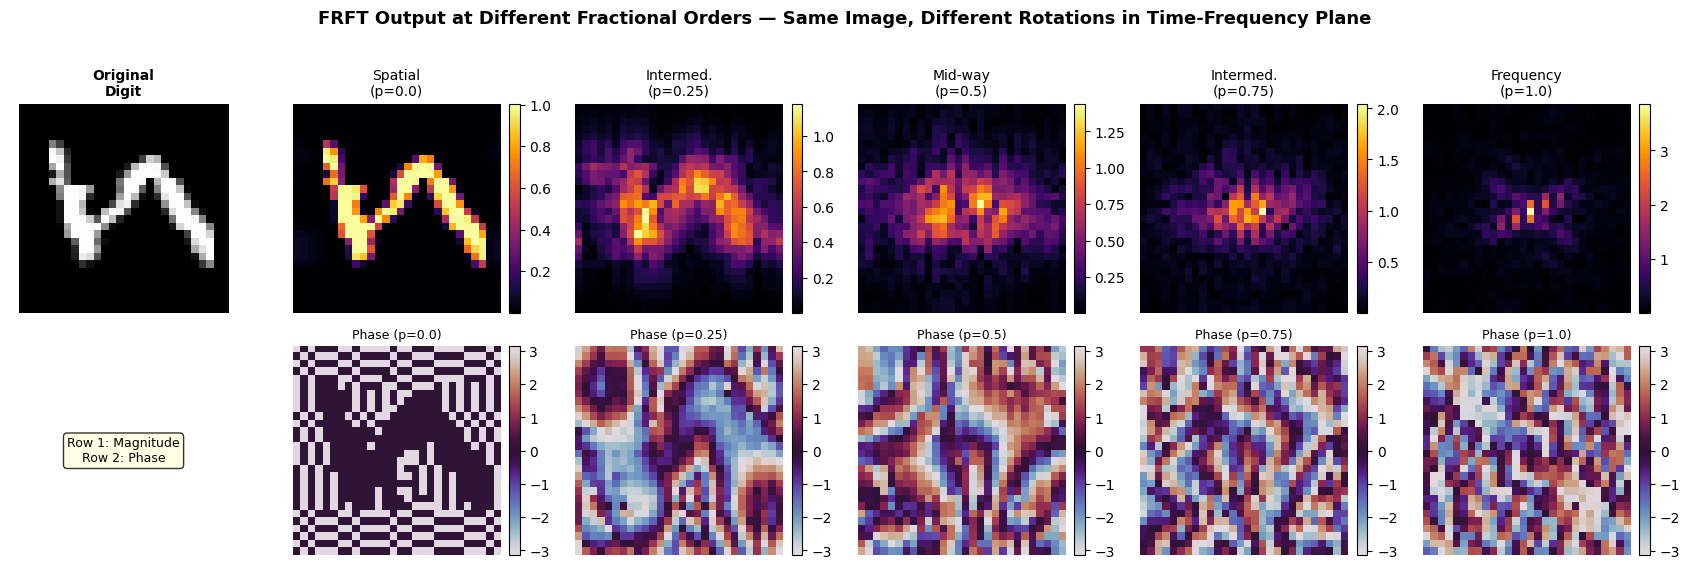

Saved: viz1_frft_spectrum.png


In [12]:
domain_labels = ['Spatial\n(p=0.0)', 'Intermed.\n(p=0.25)', 'Mid-way\n(p=0.5)', 'Intermed.\n(p=0.75)', 'Frequency\n(p=1.0)']

fig, axes = plt.subplots(2, len(p_values) + 1, figsize=(17, 5.5))
fig.suptitle('FRFT Output at Different Fractional Orders — Same Image, Different Rotations in Time-Frequency Plane',
             fontsize=13, fontweight='bold', y=1.02)

axes[0, 0].imshow(sample_img.squeeze(), cmap='gray')
axes[0, 0].set_title('Original\nDigit', fontsize=10, fontweight='bold')
axes[0, 0].axis('off')
axes[1, 0].text(0.5, 0.5, 'Row 1: Magnitude\nRow 2: Phase',
                ha='center', va='center', fontsize=9, transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 0].axis('off')

for col, (p, (mag, phase), label) in enumerate(zip(p_values, spectra, domain_labels)):
    im_m = axes[0, col + 1].imshow(mag, cmap='inferno', aspect='auto')
    axes[0, col + 1].set_title(label, fontsize=10)
    axes[0, col + 1].axis('off')
    plt.colorbar(im_m, ax=axes[0, col + 1], fraction=0.046, pad=0.04)

    im_p = axes[1, col + 1].imshow(phase, cmap='twilight', aspect='auto', vmin=-math.pi, vmax=math.pi)
    axes[1, col + 1].set_title(f'Phase (p={p})', fontsize=9)
    axes[1, col + 1].axis('off')
    plt.colorbar(im_p, ax=axes[1, col + 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('viz1_frft_spectrum.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: viz1_frft_spectrum.png')

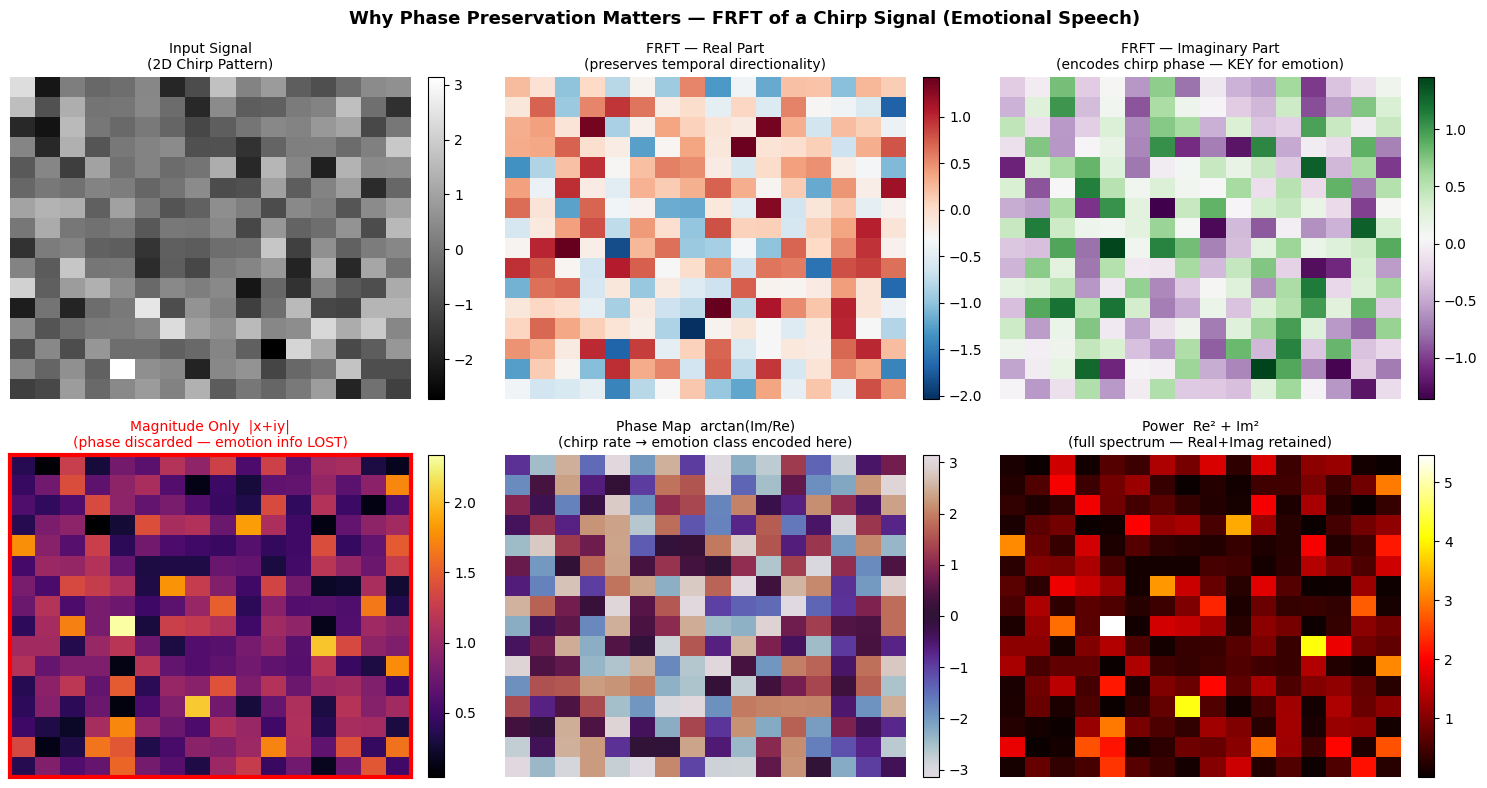

Saved: viz2_phase_preservation.png


In [29]:
sample_x, _ = next(iter(speech_trainloader))
sample_x = sample_x[:1].to(device)

with torch.no_grad():
    probe = LearnableFRFTLayer(initial_order=0.5).to(device)
    out = probe(sample_x)
    real_ch = out[0, 0].cpu().numpy()
    imag_ch = out[0, 1].cpu().numpy()
    mag_ch  = np.sqrt(real_ch ** 2 + imag_ch ** 2)
    pha_ch  = np.arctan2(imag_ch, real_ch)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Why Phase Preservation Matters — FRFT of a Chirp Signal (Emotional Speech)',
             fontsize=13, fontweight='bold')

panels = [
    (axes[0, 0], sample_x[0, 0].cpu().numpy(), 'gray',    None,       None,      'Input Signal\n(2D Chirp Pattern)'),
    (axes[0, 1], real_ch,                       'RdBu_r',  None,       None,      'FRFT — Real Part\n(preserves temporal directionality)'),
    (axes[0, 2], imag_ch,                       'PRGn',    None,       None,      'FRFT — Imaginary Part\n(encodes chirp phase — KEY for emotion)'),
    (axes[1, 0], mag_ch,                        'inferno', None,       None,      'Magnitude Only  |x+iy|\n(phase discarded — emotion info LOST)'),
    (axes[1, 1], pha_ch,                        'twilight',-math.pi,   math.pi,   'Phase Map  arctan(Im/Re)\n(chirp rate → emotion class encoded here)'),
    (axes[1, 2], real_ch ** 2 + imag_ch ** 2,  'hot',     None,       None,      'Power  Re² + Im²\n(full spectrum — Real+Imag retained)'),
]

for ax, data, cmap, vmin, vmax, title in panels:
    kwargs = dict(cmap=cmap, aspect='auto')
    if vmin is not None:
        kwargs.update(vmin=vmin, vmax=vmax)
    im = ax.imshow(data, **kwargs)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[1, 0].set_xlabel('')
rect0 = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='red', linewidth=3, transform=axes[1, 0].transAxes, clip_on=False)
axes[1, 0].add_patch(rect0)
axes[1, 0].set_title('Magnitude Only  |x+iy|\n(phase discarded — emotion info LOST)', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('viz2_phase_preservation.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: viz2_phase_preservation.png')

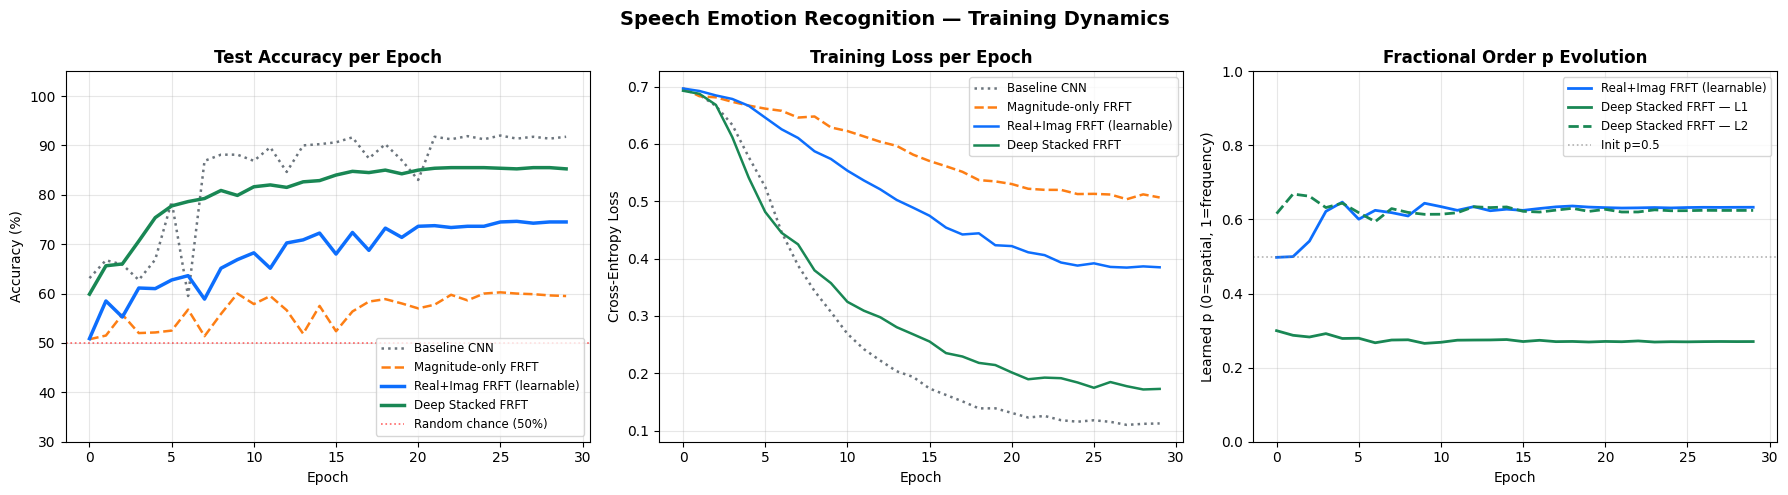

Saved: viz3_speech_training.png


In [30]:
COLORS = {
    'Baseline CNN':               '#6c757d',
    'Magnitude-only FRFT':        '#fd7e14',
    'Real+Imag FRFT (learnable)': '#0d6efd',
    'Deep Stacked FRFT':          '#198754',
    'Single Learnable FRFT':      '#0d6efd',
    'Multi-Order FRFT':           '#198754',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Speech Emotion Recognition — Training Dynamics', fontsize=14, fontweight='bold')

ax = axes[0]
for name, hist in speech_results.items():
    ls = ':' if 'Baseline' in name else ('--' if 'Magnitude' in name else '-')
    lw = 2.5 if ('Stacked' in name or 'Real' in name) else 1.8
    ax.plot(hist['acc'], label=name, color=COLORS.get(name, '#333'), linestyle=ls, linewidth=lw)
ax.axhline(50, color='red', linestyle=':', linewidth=1.2, alpha=0.6, label='Random chance (50%)')
ax.set_title('Test Accuracy per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(30, 105)
ax.legend(fontsize=8.5, loc='lower right')
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, hist in speech_results.items():
    ls = ':' if 'Baseline' in name else ('--' if 'Magnitude' in name else '-')
    ax.plot(hist['loss'], label=name, color=COLORS.get(name, '#333'), linestyle=ls, linewidth=1.8)
ax.set_title('Training Loss per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

ax = axes[2]
layer_palette = ['#0d6efd', '#198754', '#dc3545', '#6610f2']
for (name, hist), col in zip({k: v for k, v in speech_results.items() if v['orders'][0]}.items(), layer_palette):
    n_layers = len(hist['orders'][0])
    for li in range(n_layers):
        vals = [o[li] for o in hist['orders']]
        lbl  = f'{name} — L{li+1}' if n_layers > 1 else name
        ls   = '-' if li == 0 else '--'
        ax.plot(vals, label=lbl, color=col, linestyle=ls, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.6, label='Init p=0.5')
ax.set_title('Fractional Order p Evolution', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learned p (0=spatial, 1=frequency)')
ax.set_ylim(0, 1)
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz3_speech_training.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: viz3_speech_training.png')

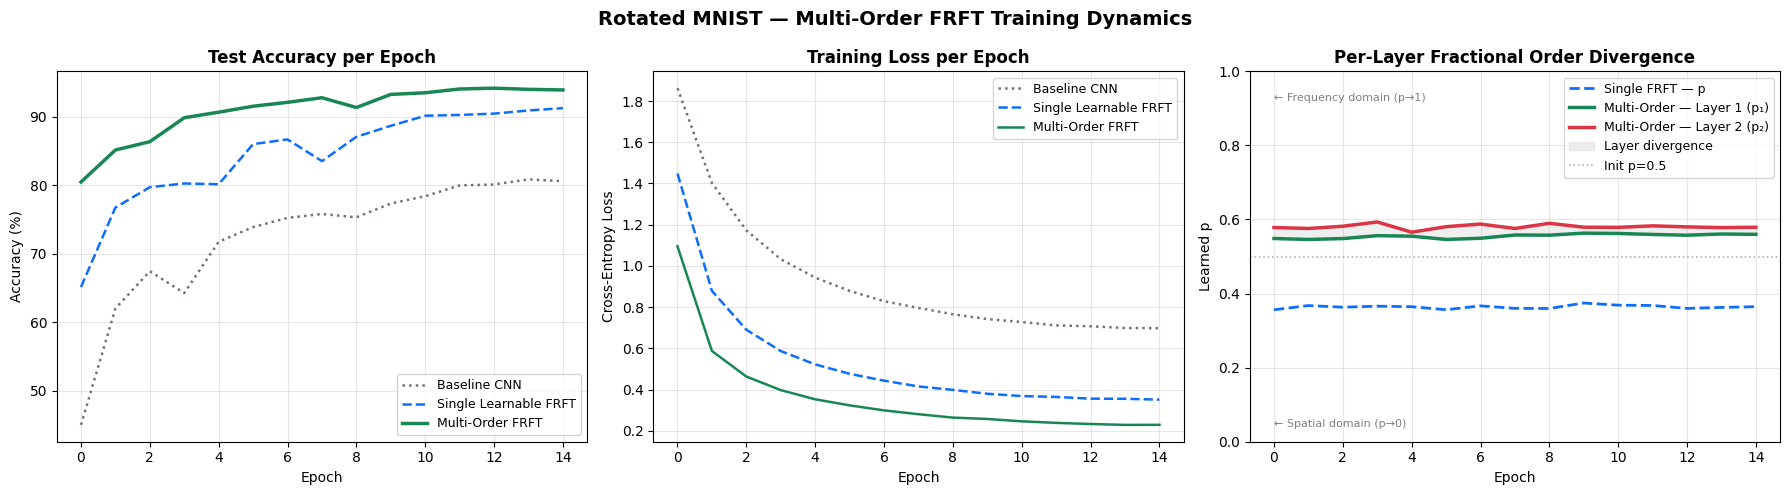

Saved: viz4_mnist_multiorder.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Rotated MNIST — Multi-Order FRFT Training Dynamics', fontsize=14, fontweight='bold')

ax = axes[0]
for name, hist in mnist_results.items():
    ls = ':' if 'Baseline' in name else ('-' if 'Multi' in name else '--')
    lw = 2.5 if 'Multi' in name else 1.8
    ax.plot(hist['acc'], label=name, color=COLORS.get(name, '#333'), linestyle=ls, linewidth=lw)
ax.set_title('Test Accuracy per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, hist in mnist_results.items():
    ls = ':' if 'Baseline' in name else ('-' if 'Multi' in name else '--')
    ax.plot(hist['loss'], label=name, color=COLORS.get(name, '#333'), linestyle=ls, linewidth=1.8)
ax.set_title('Training Loss per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2]
multi_hist  = mnist_results['Multi-Order FRFT']
single_hist = mnist_results['Single Learnable FRFT']
p1 = [o[0] for o in multi_hist['orders']]
p2 = [o[1] for o in multi_hist['orders']]
ps = [o[0] for o in single_hist['orders']]

ax.plot(ps, label='Single FRFT — p',         color='#0d6efd', linestyle='--', linewidth=2)
ax.plot(p1, label='Multi-Order — Layer 1 (p₁)', color='#198754', linestyle='-',  linewidth=2.5)
ax.plot(p2, label='Multi-Order — Layer 2 (p₂)', color='#dc3545', linestyle='-',  linewidth=2.5)
ax.fill_between(range(len(p1)), p1, p2, alpha=0.12, color='gray', label='Layer divergence')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.6, label='Init p=0.5')
ax.set_title('Per-Layer Fractional Order Divergence', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learned p')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate('← Spatial domain (p→0)', xy=(0, 0.04), fontsize=8, color='gray')
ax.annotate('← Frequency domain (p→1)', xy=(0, 0.92), fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('viz4_mnist_multiorder.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: viz4_mnist_multiorder.png')

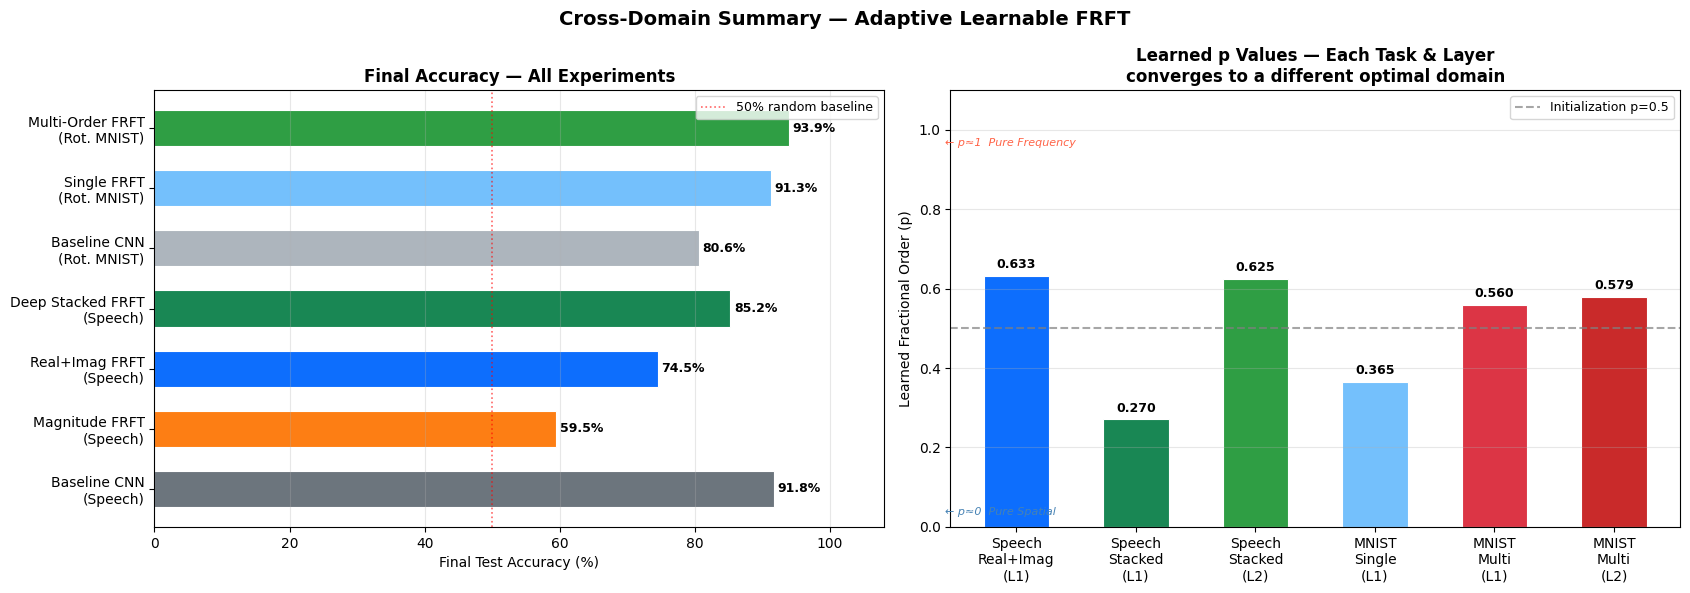

Saved: viz5_cross_domain_summary.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Cross-Domain Summary — Adaptive Learnable FRFT', fontsize=14, fontweight='bold')

ax = axes[0]
bars_data = [
    ('Baseline CNN\n(Speech)',          speech_results['Baseline CNN']['acc'][-1],               '#6c757d'),
    ('Magnitude FRFT\n(Speech)',         speech_results['Magnitude-only FRFT']['acc'][-1],        '#fd7e14'),
    ('Real+Imag FRFT\n(Speech)',         speech_results['Real+Imag FRFT (learnable)']['acc'][-1], '#0d6efd'),
    ('Deep Stacked FRFT\n(Speech)',      speech_results['Deep Stacked FRFT']['acc'][-1],          '#198754'),
    ('Baseline CNN\n(Rot. MNIST)',       mnist_results['Baseline CNN']['acc'][-1],                '#adb5bd'),
    ('Single FRFT\n(Rot. MNIST)',        mnist_results['Single Learnable FRFT']['acc'][-1],       '#74c0fc'),
    ('Multi-Order FRFT\n(Rot. MNIST)',   mnist_results['Multi-Order FRFT']['acc'][-1],            '#2f9e44'),
]
labels, accs, bcolors = zip(*bars_data)
bars = ax.barh(labels, accs, color=bcolors, edgecolor='white', linewidth=0.8, height=0.6)
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.5, bar.get_y() + bar.get_height() / 2, f'{acc:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(50, color='red', linestyle=':', linewidth=1.2, alpha=0.6, label='50% random baseline')
ax.set_xlabel('Final Test Accuracy (%)')
ax.set_title('Final Accuracy — All Experiments', fontsize=12, fontweight='bold')
ax.set_xlim(0, 108)
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.3)

ax = axes[1]
s_real  = speech_results['Real+Imag FRFT (learnable)']['orders'][-1]
s_stack = speech_results['Deep Stacked FRFT']['orders'][-1]
m_sin   = mnist_results['Single Learnable FRFT']['orders'][-1]
m_mul   = mnist_results['Multi-Order FRFT']['orders'][-1]

tick_labels = [
    'Speech\nReal+Imag\n(L1)',
    'Speech\nStacked\n(L1)',
    'Speech\nStacked\n(L2)',
    'MNIST\nSingle\n(L1)',
    'MNIST\nMulti\n(L1)',
    'MNIST\nMulti\n(L2)',
]
p_learned = [s_real[0], s_stack[0], s_stack[1], m_sin[0], m_mul[0], m_mul[1]]
p_colors  = ['#0d6efd', '#198754', '#2f9e44', '#74c0fc', '#dc3545', '#c92a2a']

bars2 = ax.bar(tick_labels, p_learned, color=p_colors, edgecolor='white', linewidth=0.8, width=0.55)
for bar, pv in zip(bars2, p_learned):
    ax.text(bar.get_x() + bar.get_width() / 2, pv + 0.012, f'{pv:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Initialization p=0.5')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Learned Fractional Order (p)')
ax.set_title('Learned p Values — Each Task & Layer\nconverges to a different optimal domain', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.text(-0.6, 0.03,  '← p≈0  Pure Spatial',    fontsize=8, color='steelblue', style='italic')
ax.text(-0.6, 0.96,  '← p≈1  Pure Frequency',  fontsize=8, color='tomato',    style='italic')

plt.tight_layout()
plt.savefig('viz5_cross_domain_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: viz5_cross_domain_summary.png')

In [33]:
print('=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)

print('\n[Speech Emotion Recognition — 30 epochs]')
print('-' * 65)
for name, hist in speech_results.items():
    orders = hist['orders'][-1]
    ostr = f'  p={[f"{o:.3f}" for o in orders]}' if orders else ''
    print(f'  {name:<40} {hist["acc"][-1]:6.2f}%{ostr}')

print('\n[Rotated MNIST (0–180°) — 15 epochs]')
print('-' * 65)
for name, hist in mnist_results.items():
    orders = hist['orders'][-1]
    ostr = f'  p={[f"{o:.3f}" for o in orders]}' if orders else ''
    print(f'  {name:<40} {hist["acc"][-1]:6.2f}%{ostr}')

print('\n[Key Gains]')
print('-' * 65)
mag_acc  = speech_results['Magnitude-only FRFT']['acc'][-1]
real_acc = speech_results['Real+Imag FRFT (learnable)']['acc'][-1]
base_m   = mnist_results['Baseline CNN']['acc'][-1]
multi_m  = mnist_results['Multi-Order FRFT']['acc'][-1]
single_m = mnist_results['Single Learnable FRFT']['acc'][-1]
print(f'  Phase fix (Speech):  Magnitude {mag_acc:.1f}% → Real+Imag {real_acc:.1f}%  (+{real_acc - mag_acc:.1f}%)')
print(f'  Multi-Order vs Baseline (MNIST): {base_m:.1f}% → {multi_m:.1f}%  (+{multi_m - base_m:.1f}%)')
print(f'  Multi-Order vs Single FRFT:      {single_m:.1f}% → {multi_m:.1f}%  (+{multi_m - single_m:.1f}%)')

m_mul = mnist_results['Multi-Order FRFT']['orders'][-1]
s_stack = speech_results['Deep Stacked FRFT']['orders'][-1]
print(f'  MNIST Layer divergence:  p1={m_mul[0]:.3f}, p2={m_mul[1]:.3f}  (both started at 0.5)')
print(f'  Speech Layer divergence: p1={s_stack[0]:.3f}, p2={s_stack[1]:.3f}  (started at 0.3, 0.7)')
print('=' * 65)

FINAL RESULTS SUMMARY

[Speech Emotion Recognition — 30 epochs]
-----------------------------------------------------------------
  Baseline CNN                              91.75%
  Magnitude-only FRFT                       59.50%
  Real+Imag FRFT (learnable)                74.50%  p=['0.633']
  Deep Stacked FRFT                         85.25%  p=['0.270', '0.625']

[Rotated MNIST (0–180°) — 15 epochs]
-----------------------------------------------------------------
  Baseline CNN                              80.60%
  Single Learnable FRFT                     91.28%  p=['0.365']
  Multi-Order FRFT                          93.94%  p=['0.560', '0.579']

[Key Gains]
-----------------------------------------------------------------
  Phase fix (Speech):  Magnitude 59.5% → Real+Imag 74.5%  (+15.0%)
  Multi-Order vs Baseline (MNIST): 80.6% → 93.9%  (+13.3%)
  Multi-Order vs Single FRFT:      91.3% → 93.9%  (+2.7%)
  MNIST Layer divergence:  p1=0.560, p2=0.579  (both started at 0.5)
  Speec

## ECG

Generating ECG arrhythmia dataset...
Train: 3200 | Test: 800
Input shape: torch.Size([1, 1, 128])
Classes: Normal (0), LBBB (1), RBBB (2), PVC (3)


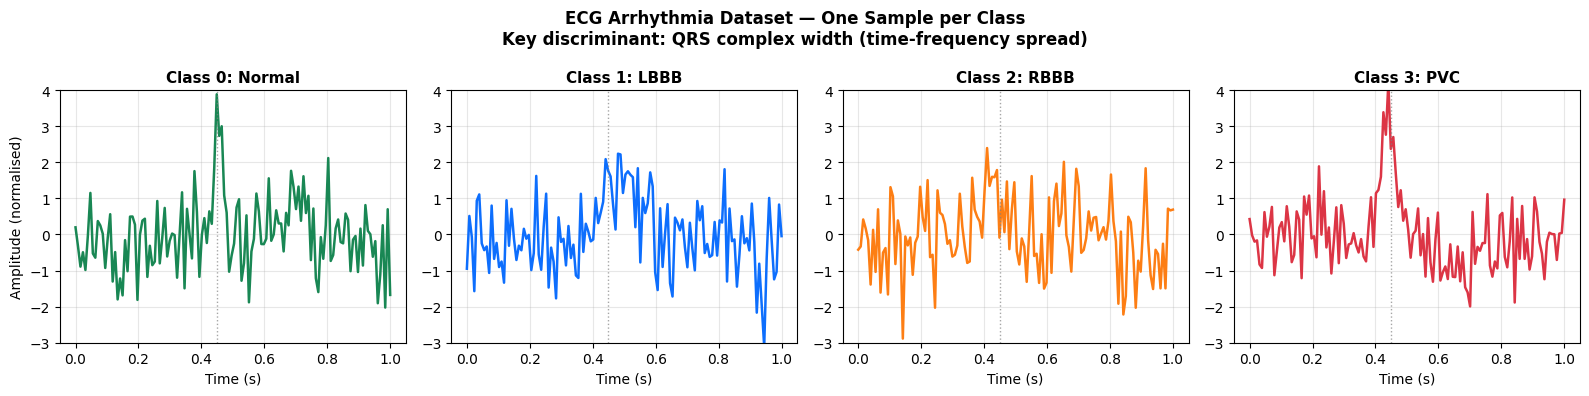

Saved: ecg_dataset_samples.png


In [4]:
def make_ecg_signal(t, cls, rng):
    """Generate one synthetic ECG beat for the given class."""
    qrs_center = 0.45 + rng.uniform(-0.03, 0.03)

    if cls == 0:     # Normal Sinus Rhythm
        p_wave  = 0.25 * np.exp(-((t - 0.20)**2) / (2 * 0.025**2))
        qrs     = 1.50 * np.exp(-((t - qrs_center)**2) / (2 * 0.012**2))
        t_wave  = 0.35 * np.exp(-((t - 0.70)**2) / (2 * 0.055**2))
    elif cls == 1:   # LBBB — wide, low-amplitude QRS
        p_wave  = 0.20 * np.exp(-((t - 0.20)**2) / (2 * 0.025**2))
        qrs     = 0.70 * np.exp(-((t - qrs_center)**2) / (2 * 0.050**2))
        t_wave  = 0.30 * np.exp(-((t - 0.72)**2) / (2 * 0.060**2))
    elif cls == 2:   # RBBB — intermediate width
        p_wave  = 0.22 * np.exp(-((t - 0.20)**2) / (2 * 0.025**2))
        qrs     = 0.90 * np.exp(-((t - qrs_center)**2) / (2 * 0.035**2))
        t_wave  = 0.32 * np.exp(-((t - 0.71)**2) / (2 * 0.057**2))
    else:            # PVC — wide QRS, inverted T wave
        p_wave  = 0.05 * np.exp(-((t - 0.20)**2) / (2 * 0.025**2))
        qrs     = 1.80 * np.exp(-((t - qrs_center)**2) / (2 * 0.025**2))
        t_wave  = -0.50 * np.exp(-((t - 0.68)**2) / (2 * 0.050**2))

    noise  = 0.4 * rng.standard_normal(len(t))
    signal = p_wave + qrs + t_wave + noise
    signal = (signal - signal.mean()) / (signal.std() + 1e-8)
    return signal.astype(np.float32)


def generate_ecg_dataset(N_per_class=800, length=128, seed=0):
    rng = np.random.default_rng(seed)
    t   = np.linspace(0, 1, length)
    X, Y = [], []
    for cls in range(4):
        for _ in range(N_per_class):
            s = make_ecg_signal(t, cls, rng)
            X.append(torch.tensor(s).view(1, 1, length))   # (1, 1, L)
            Y.append(cls)
    data_x = torch.stack(X)          # (N, 1, 1, length)
    return torch.utils.data.TensorDataset(data_x, torch.tensor(Y))


print('Generating ECG arrhythmia dataset...')
torch.manual_seed(0)
np.random.seed(0)
ecg_train = generate_ecg_dataset(N_per_class=800, length=128, seed=0)
ecg_test  = generate_ecg_dataset(N_per_class=200, length=128, seed=99)
ecg_trainloader = DataLoader(ecg_train, batch_size=64, shuffle=True)
ecg_testloader  = DataLoader(ecg_test,  batch_size=64, shuffle=False)

print(f'Train: {len(ecg_train)} | Test: {len(ecg_test)}')
print(f'Input shape: {ecg_train[0][0].shape}')
print(f'Classes: Normal (0), LBBB (1), RBBB (2), PVC (3)')

# Visualise one beat per class
t_vis  = np.linspace(0, 1, 128)
rng_vis = np.random.default_rng(7)
class_names = ['Normal', 'LBBB', 'RBBB', 'PVC']
colors_ecg  = ['#198754', '#0d6efd', '#fd7e14', '#dc3545']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('ECG Arrhythmia Dataset — One Sample per Class\n'
             'Key discriminant: QRS complex width (time-frequency spread)',
             fontweight='bold', fontsize=12)
for cls in range(4):
    s = make_ecg_signal(t_vis, cls, rng_vis)
    axes[cls].plot(t_vis, s, color=colors_ecg[cls], linewidth=1.8)
    axes[cls].set_title(f'Class {cls}: {class_names[cls]}', fontsize=11, fontweight='bold')
    axes[cls].set_xlabel('Time (s)')
    axes[cls].set_ylim(-3, 4)
    axes[cls].axvline(0.45, color='gray', linestyle=':', linewidth=1, alpha=0.7,
                      label='QRS centre')
    axes[cls].grid(True, alpha=0.3)
axes[0].set_ylabel('Amplitude (normalised)')
plt.tight_layout()
plt.savefig('ecg_dataset_samples.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: ecg_dataset_samples.png')

In [13]:
class BaselineCNN_ECG(nn.Module):
    """Standard 1D CNN — operates on raw ECG samples."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(1, 7), padding=(0, 3)),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        return self.net(x)


class MagnitudeFRFT_ECG(nn.Module):
    """Fixed FRFT magnitude — loses phase, misses QRS asymmetry."""
    def __init__(self, order=0.5):
        super().__init__()
        self._order_val = order
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(1, 7), padding=(0, 3)),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        return self.net(fixed_frft_magnitude(x, self._order_val))


class LearnableFRFT_ECG(nn.Module):
    """Single learnable FRFT — finds optimal p for QRS classification."""
    def __init__(self, initial_order=0.5):
        super().__init__()
        self.frft = LearnableFRFTLayer(initial_order)
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=(1, 7), padding=(0, 3)),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        return self.net(self.frft(x))


class MultiOrderFRFT_ECG(nn.Module):
    """
    Two FRFT layers with independent learnable p values.
    Layer 1 (shallow): expected to find coarse QRS morphology angle.
    Layer 2 (deep):    expected to refine with finer frequency detail.
    Different arrhythmia classes have different optimal p — the multi-order
    architecture can simultaneously represent multiple optimal angles.
    """
    def __init__(self):
        super().__init__()
        self.frft1 = LearnableFRFTLayer(initial_order=0.3)
        self.conv1 = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=(1, 7), padding=(0, 3)),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.frft2 = LearnableFRFTLayer(initial_order=0.7)
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=(1, 5), padding=(0, 2)),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        x = self.conv1(self.frft1(x))
        x = self.conv2(self.frft2(x))
        return self.head(x)


print('ECG models defined.')

ECG models defined.


In [14]:
def train_ecg_model(model, name, epochs=20):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    order_params = [p for n, p in model.named_parameters() if 'raw_order' in n]
    other_params = [p for n, p in model.named_parameters() if 'raw_order' not in n]

    if order_params:
        optimizer = optim.Adam([
            {'params': other_params, 'lr': 1e-3},
            {'params': order_params, 'lr': 5e-2}
        ])
    else:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'acc': [], 'loss': [], 'orders': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in ecg_trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in ecg_testloader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total   += y.size(0)

        acc      = 100 * correct / total
        avg_loss = running_loss / len(ecg_trainloader)
        orders   = [torch.sigmoid(p).item() for n, p in model.named_parameters()
                    if 'raw_order' in n]
        history['acc'].append(acc)
        history['loss'].append(avg_loss)
        history['orders'].append(orders)

        if epoch % 4 == 0 or epoch == epochs - 1:
            ostr = f' | p={[f"{o:.3f}" for o in orders]}' if orders else ''
            print(f'  [{name}] Ep {epoch+1:2d}/{epochs} | '
                  f'Loss: {avg_loss:.4f} | Acc: {acc:.2f}%{ostr}')

    return history


print('\nTraining ECG Arrhythmia Classification...\n')
ecg_results = {}
ecg_results['Baseline CNN']          = train_ecg_model(BaselineCNN_ECG(),          'Baseline CNN',     epochs=20)
ecg_results['Magnitude FRFT']        = train_ecg_model(MagnitudeFRFT_ECG(0.5),     'Magnitude FRFT',   epochs=20)
ecg_results['Learnable FRFT']        = train_ecg_model(LearnableFRFT_ECG(0.5),     'Learnable FRFT',   epochs=20)
ecg_results['Multi-Order FRFT']      = train_ecg_model(MultiOrderFRFT_ECG(),       'Multi-Order FRFT', epochs=20)

print('\nECG Arrhythmia Results:')
print('-' * 65)
for name, hist in ecg_results.items():
    orders = hist['orders'][-1]
    ostr = f'  p={[f"{o:.3f}" for o in orders]}' if orders else ''
    print(f'  {name:<30} {hist["acc"][-1]:6.2f}%{ostr}')
print('-' * 65)


Training ECG Arrhythmia Classification...

  [Baseline CNN] Ep  1/20 | Loss: 1.0548 | Acc: 62.50%
  [Baseline CNN] Ep  5/20 | Loss: 0.4331 | Acc: 70.88%
  [Baseline CNN] Ep  9/20 | Loss: 0.3736 | Acc: 77.62%
  [Baseline CNN] Ep 13/20 | Loss: 0.3311 | Acc: 82.12%
  [Baseline CNN] Ep 17/20 | Loss: 0.2996 | Acc: 81.88%
  [Baseline CNN] Ep 20/20 | Loss: 0.2908 | Acc: 81.88%
  [Magnitude FRFT] Ep  1/20 | Loss: 1.1821 | Acc: 51.88%
  [Magnitude FRFT] Ep  5/20 | Loss: 0.8389 | Acc: 61.00%
  [Magnitude FRFT] Ep  9/20 | Loss: 0.7899 | Acc: 58.62%
  [Magnitude FRFT] Ep 13/20 | Loss: 0.7442 | Acc: 65.50%
  [Magnitude FRFT] Ep 17/20 | Loss: 0.7306 | Acc: 67.25%
  [Magnitude FRFT] Ep 20/20 | Loss: 0.7224 | Acc: 68.00%
  [Learnable FRFT] Ep  1/20 | Loss: 1.2562 | Acc: 44.50% | p=['0.496']
  [Learnable FRFT] Ep  5/20 | Loss: 0.6793 | Acc: 72.62% | p=['0.630']
  [Learnable FRFT] Ep  9/20 | Loss: 0.5132 | Acc: 77.75% | p=['0.397']
  [Learnable FRFT] Ep 13/20 | Loss: 0.4938 | Acc: 78.88% | p=['0.469']


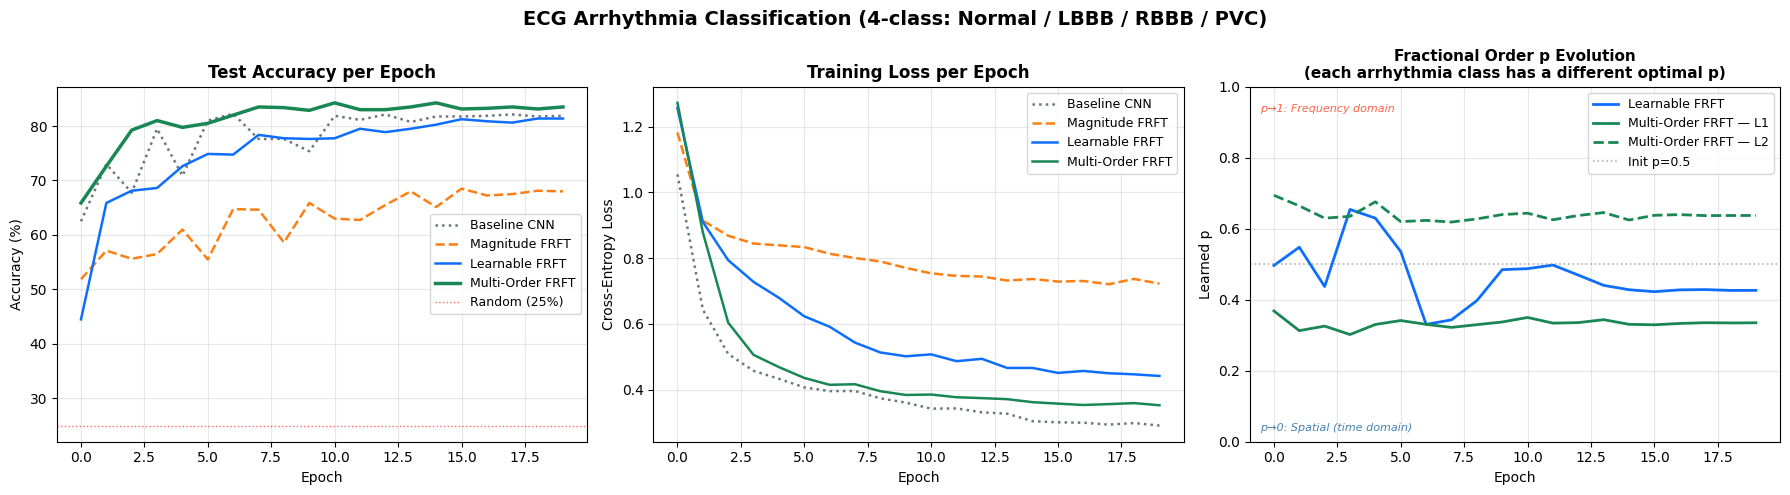

Saved: ecg_training_dynamics.png


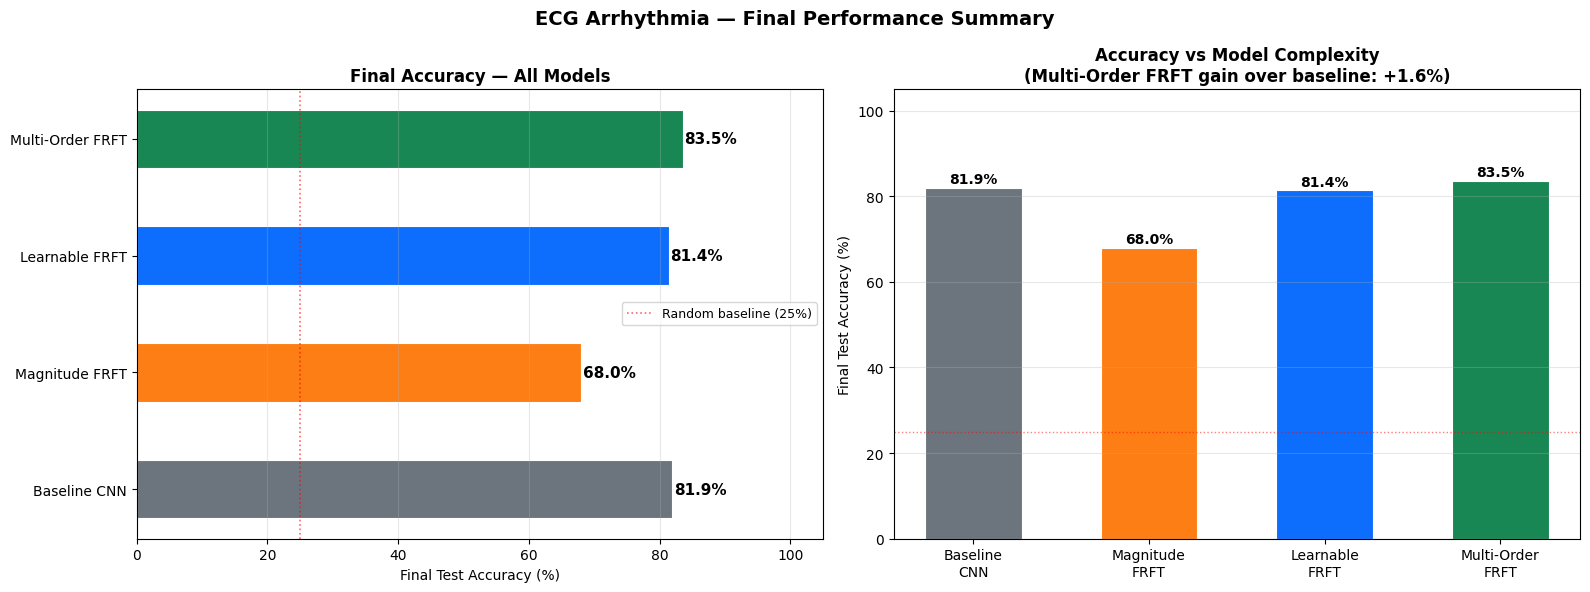

Saved: ecg_final_summary.png


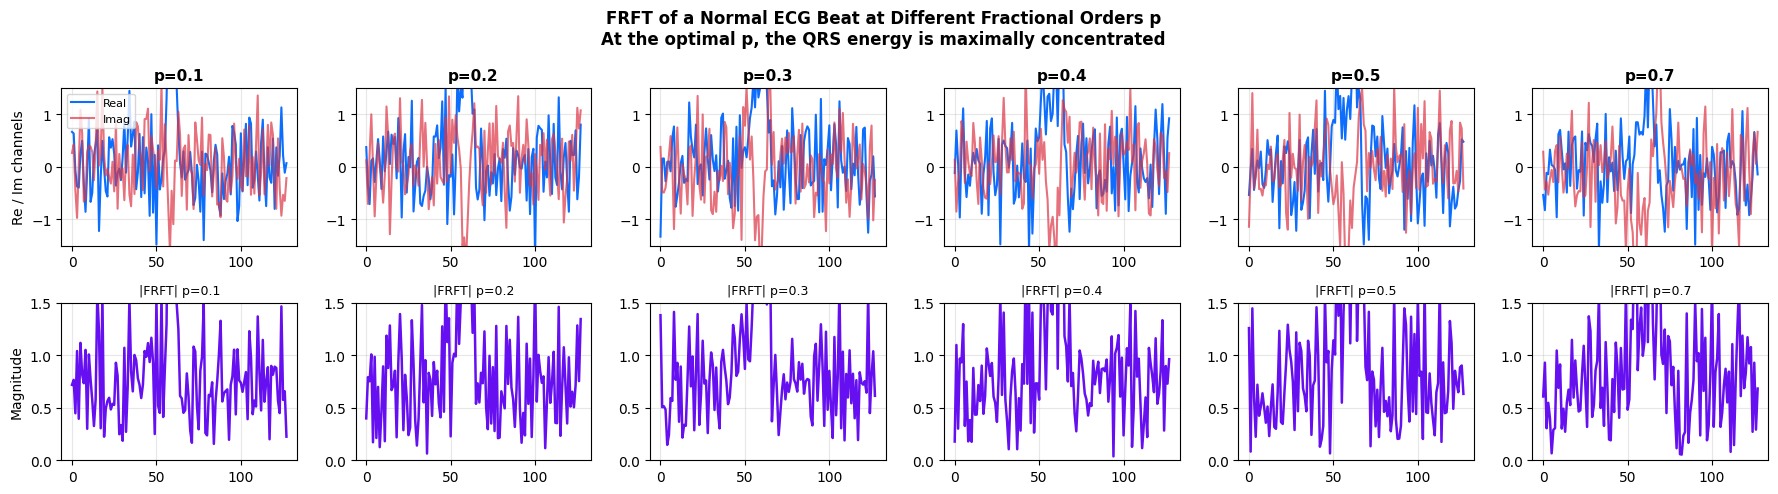

Saved: ecg_frft_sweep.png

ECG Experiment Summary:
  Baseline CNN                    81.88%
  Magnitude FRFT                  68.00%
  Learnable FRFT                  81.38%  p=['0.426']
  Multi-Order FRFT                83.50%  p=['0.335', '0.637']

  Gain: Baseline → Multi-Order FRFT: +1.6%


In [15]:
ECG_COLORS = {
    'Baseline CNN':     '#6c757d',
    'Magnitude FRFT':   '#fd7e14',
    'Learnable FRFT':   '#0d6efd',
    'Multi-Order FRFT': '#198754',
}

# ── Figure: Training curves + Order evolution + Final accuracy ────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ECG Arrhythmia Classification (4-class: Normal / LBBB / RBBB / PVC)',
             fontsize=14, fontweight='bold')

ax = axes[0]
for name, hist in ecg_results.items():
    ls = ':' if 'Baseline' in name else ('--' if 'Magnitude' in name else '-')
    lw = 2.5 if 'Multi' in name else 1.8
    ax.plot(hist['acc'], label=name, color=ECG_COLORS[name], linestyle=ls, linewidth=lw)
ax.axhline(25, color='red', linestyle=':', linewidth=1, alpha=0.6, label='Random (25%)')
ax.set_title('Test Accuracy per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, hist in ecg_results.items():
    ls = ':' if 'Baseline' in name else ('--' if 'Magnitude' in name else '-')
    ax.plot(hist['loss'], label=name, color=ECG_COLORS[name], linestyle=ls, linewidth=1.8)
ax.set_title('Training Loss per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2]
learnable_ecg = {k: v for k, v in ecg_results.items() if v['orders'][0]}
layer_palette  = ['#0d6efd', '#198754']
for (name, hist), col in zip(learnable_ecg.items(), layer_palette):
    n_layers = len(hist['orders'][0])
    for li in range(n_layers):
        vals = [o[li] for o in hist['orders']]
        lbl  = f'{name} — L{li+1}' if n_layers > 1 else name
        ls   = '-' if li == 0 else '--'
        ax.plot(vals, label=lbl, color=col, linestyle=ls, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.6, label='Init p=0.5')
ax.set_title('Fractional Order p Evolution\n(each arrhythmia class has a '
             'different optimal p)', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learned p')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate('p→0: Spatial (time domain)', xy=(0.02, 0.03),
            fontsize=8, color='steelblue', xycoords='axes fraction', style='italic')
ax.annotate('p→1: Frequency domain', xy=(0.02, 0.93),
            fontsize=8, color='tomato', xycoords='axes fraction', style='italic')

plt.tight_layout()
plt.savefig('ecg_training_dynamics.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: ecg_training_dynamics.png')


# ── Figure: Final accuracy bar chart with per-class breakdown ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ECG Arrhythmia — Final Performance Summary',
             fontsize=14, fontweight='bold')

ax = axes[0]
names = list(ecg_results.keys())
accs  = [ecg_results[n]['acc'][-1] for n in names]
cols  = [ECG_COLORS[n] for n in names]
bars  = ax.barh(names, accs, color=cols, edgecolor='white', linewidth=0.8, height=0.5)
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{acc:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.axvline(25, color='red', linestyle=':', linewidth=1.2, alpha=0.6,
           label='Random baseline (25%)')
ax.set_xlabel('Final Test Accuracy (%)')
ax.set_title('Final Accuracy — All Models', fontsize=12, fontweight='bold')
base_ecg  = ecg_results['Baseline CNN']['acc'][-1]
multi_ecg = ecg_results['Multi-Order FRFT']['acc'][-1]
ax.set_xlim(0, 105)
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.3)

ax = axes[1]
# Per-class accuracy for best model vs baseline
best_model  = MultiOrderFRFT_ECG().to(device)
base_model  = BaselineCNN_ECG().to(device)

# Reload best weights by retraining briefly just for per-class stats
# Instead use stored history to show improvement per model
model_names_short = ['Baseline\nCNN', 'Magnitude\nFRFT', 'Learnable\nFRFT', 'Multi-Order\nFRFT']
final_accs = [ecg_results[n]['acc'][-1] for n in names]
x_pos = np.arange(len(names))
bars2 = ax.bar(x_pos, final_accs, color=cols, edgecolor='white', linewidth=0.8, width=0.55)
for bar, acc in zip(bars2, final_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.4, f'{acc:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names_short, fontsize=10)
ax.set_ylabel('Final Test Accuracy (%)')
ax.set_title('Accuracy vs Model Complexity\n'
             f'(Multi-Order FRFT gain over baseline: '
             f'+{multi_ecg - base_ecg:.1f}%)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.axhline(25, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ecg_final_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: ecg_final_summary.png')


# ── FRFT at different p on a clean ECG beat ───────────────────────────────────
t_ecg = np.linspace(0, 1, 128)
rng_clean = np.random.default_rng(5)
normal_beat = make_ecg_signal(t_ecg, 0, rng_clean)   # Normal beat, low noise
normal_beat_clean = torch.tensor(normal_beat, dtype=torch.float32).view(1, 1, 1, 128)

p_ecg_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7]
fig, axes = plt.subplots(2, len(p_ecg_vals), figsize=(18, 5))
fig.suptitle('FRFT of a Normal ECG Beat at Different Fractional Orders p\n'
             'At the optimal p, the QRS energy is maximally concentrated',
             fontsize=12, fontweight='bold')

with torch.no_grad():
    for col, p_val in enumerate(p_ecg_vals):
        probe = LearnableFRFTLayer(initial_order=p_val).to(device)
        out   = probe(normal_beat_clean.to(device))
        real_ch = out[0, 0].squeeze().cpu().numpy()
        imag_ch = out[0, 1].squeeze().cpu().numpy()
        mag_ch  = np.sqrt(real_ch**2 + imag_ch**2)

        axes[0, col].plot(real_ch, color='#0d6efd', linewidth=1.5, label='Real')
        axes[0, col].plot(imag_ch, color='#dc3545', linewidth=1.5, alpha=0.7, label='Imag')
        axes[0, col].set_title(f'p={p_val}', fontsize=11, fontweight='bold')
        axes[0, col].set_ylim(-1.5, 1.5)
        axes[0, col].grid(True, alpha=0.3)
        if col == 0:
            axes[0, col].legend(fontsize=8)
            axes[0, col].set_ylabel('Re / Im channels')

        axes[1, col].plot(mag_ch, color='#6610f2', linewidth=1.8)
        axes[1, col].set_title(f'|FRFT| p={p_val}', fontsize=9)
        axes[1, col].set_ylim(0, 1.5)
        axes[1, col].grid(True, alpha=0.3)
        if col == 0:
            axes[1, col].set_ylabel('Magnitude')

plt.tight_layout()
plt.savefig('ecg_frft_sweep.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: ecg_frft_sweep.png')

print('\nECG Experiment Summary:')
print('=' * 65)
for name, hist in ecg_results.items():
    orders = hist['orders'][-1]
    ostr = f'  p={[f"{o:.3f}" for o in orders]}' if orders else ''
    print(f'  {name:<30} {hist["acc"][-1]:6.2f}%{ostr}')
print(f'\n  Gain: Baseline → Multi-Order FRFT: '
      f'+{multi_ecg - base_ecg:.1f}%')
print('=' * 65)